In [ ]:
!pip install pillow-heif # Install necessary package for HEIC support
!pip install pillow-heif # Install necessary package for HEIC support


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 25.8 MB/s eta 0:00:00


In [ ]:
from PIL import Image
from pillow_heif import register_heif_opener # Import for registering HEIC support
import numpy as np
import cv2
import os
import re



from google.colab.patches import cv2_imshow  # Para mostrar imágenes en Colab

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls '/content/drive/MyDrive/PathologIA-Images/AMELOBLASTOMA 2025/40x y 60x/60X'



'Copy of IMG_1424.HEIC'  'Copy of IMG_1496.HEIC'      'Copy of IMG_1568.HEIC'
'Copy of IMG_1425.HEIC'  'Copy of IMG_1497.HEIC'      'Copy of IMG_1569 (1).HEIC'
'Copy of IMG_1426.HEIC'  'Copy of IMG_1498.HEIC'      'Copy of IMG_1569.HEIC'
'Copy of IMG_1427.HEIC'  'Copy of IMG_1499.HEIC'      'Copy of IMG_1570 (1).HEIC'
'Copy of IMG_1428.HEIC'  'Copy of IMG_1500.HEIC'      'Copy of IMG_1570.HEIC'
'Copy of IMG_1429.HEIC'  'Copy of IMG_1501.HEIC'      'Copy of IMG_1571 (1).HEIC'
'Copy of IMG_1430.HEIC'  'Copy of IMG_1502.HEIC'      'Copy of IMG_1571.HEIC'
'Copy of IMG_1431.HEIC'  'Copy of IMG_1503.HEIC'      'Copy of IMG_1572.HEIC'
'Copy of IMG_1432.HEIC'  'Copy of IMG_1504.HEIC'      'Copy of IMG_1573.HEIC'
'Copy of IMG_1433.HEIC'  'Copy of IMG_1505.HEIC'      'Copy of IMG_1574.HEIC'
'Copy of IMG_1434.HEIC'  'Copy of IMG_1506.HEIC'      'Copy of IMG_1575.HEIC'
'Copy of IMG_1435.HEIC'  'Copy of IMG_1507.HEIC'      'Copy of IMG_1576.HEIC'
'Copy of IMG_1436.HEIC'  'Copy of IMG_1508.HEIC'    

In [ ]:
!ls '/content/drive/MyDrive/GorlinIA/A_D_K_CROPPED/AMELOBLASTOMA/Testing/60X'

In [ ]:
def detect_circle_and_crop_inscribed_square(min_radius, max_radius):
    # Cargar la imagen de bordes
    edges_image = edges

    # Detectar círculos en la imagen de bordes usando la Transformada de Hough
    circles = cv2.HoughCircles(
        edges_image,
        cv2.HOUGH_GRADIENT,
        dp=1.2,
        minDist=30,
        param1=50,
        param2=30,
        minRadius=min_radius,
        maxRadius=max_radius,
    )

    if circles is not None:
        # Asegurarse de que los círculos están bien definidos
        circles = np.round(circles[0, :]).astype("int")

        # Seleccionar el círculo más prominente (el más grande)
        most_prominent_circle = max(circles, key=lambda c: c[2])  # Círculo más grande
        x, y, radius = most_prominent_circle

        # Dibujar el círculo en la imagen original
        original_image = resized_image.copy()
        cv2.circle(original_image, (x, y), radius, (0, 255, 0), 3)  # Círculo verde
        cv2.circle(original_image, (x, y), 5, (0, 0, 255), -1)      # Centro en rojo

        # Calcular las coordenadas del cuadrado inscrito
        square_side = int(np.sqrt(2) * radius)  # Lado del cuadrado inscrito
        top_left_x = max(0, x - square_side // 2)
        top_left_y = max(0, y - square_side // 2)
        bottom_right_x = min(resized_image.shape[1], x + square_side // 2)
        bottom_right_y = min(resized_image.shape[0], y + square_side // 2)

        # Recortar la región del cuadrado inscrito
        square_crop = resized_image[top_left_y:bottom_right_y, top_left_x:bottom_right_x]

        # Mostrar la imagen original con el círculo
        #print(f"Círculo detectado: Centro=({x}, {y}), Radio={radius}")
        #cv2_imshow(original_image)

        # Mostrar el cuadrado recortado
        #print("Cuadrado inscrito recortado:")
        #cv2_imshow(square_crop)

        # Guardar los resultados
        cv2.imwrite("circle_detected_with_inscribed_square.jpg", original_image)
        cv2.imwrite("inscribed_square_cropped.jpg", square_crop)
        #print("Imagen con círculo guardada como 'circle_detected_with_inscribed_square.jpg'.")
        #print("Cuadrado recortado guardado como 'inscribed_square_cropped.jpg'.")
    else:
        print("No se detectaron círculos en la imagen de bordes.")
    return square_crop


In [ ]:
# Habilitar soporte para archivos HEIC en Pillow
register_heif_opener()

# Ruta al directorio donde están las imágenes
folder_path = '/content/drive/MyDrive/PathologIA-Images/SQUAMOUS CELL CARCINOMA 2025/40X y 60X/60X'
j = 1 # Contador para guardar las imágenes

# Función para extraer el número del nombre del archivo
def extract_number(file_name):
    # Buscar números en el nombre del archivo con una expresión regular
    match = re.search(r'\d+', file_name)
    return int(match.group()) if match else float('inf')  # Devuelve el número o un valor alto si no encuentra números

# Listar todos los archivos en el directorio
file_list = os.listdir(folder_path)

# Filtrar solo archivos HEIC
heic_files = [f for f in file_list if f.lower().endswith('.heic')]

# Ordenar los archivos numéricamente según los números en el nombre
sorted_files = sorted(heic_files, key=extract_number)

# Procesar los archivos ordenados
for file_name in sorted_files:
    # Construir la ruta completa del archivo
    file_path = os.path.join(folder_path, file_name)

    try:
        # Abrir la imagen
        img = Image.open(file_path)


        # Convertir la imagen de Pillow a un arreglo de NumPy (compatible con OpenCV)
        image_np = np.array(img)
        # Convertir de RGB (Pillow) a BGR (OpenCV)
        image_bgr = cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR)


        # Scale factor
        scale = 0.25

        # Calculate new dimensions
        new_width = int(image_np.shape[1] * scale)
        new_height = int(image_np.shape[0] * scale)
        new_size = (new_width, new_height)

        # Resize the image
        resized_image = cv2.resize(image_bgr, new_size, interpolation=cv2.INTER_LINEAR)

        gray = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)
        lower_threshold = 100
        upper_threshold = 500
        blurred = cv2.GaussianBlur(gray, (5, 5), 1.3)
        edges = cv2.Canny(blurred, lower_threshold, upper_threshold)

        # Parámetros para la detección de círculos
        min_radius = 100        # Radio mínimo del círculo
        max_radius = 490        # Radio máximo del círculo

        # Detectar círculo y recortar el cuadrado inscrito
        square_crop = detect_circle_and_crop_inscribed_square(min_radius, max_radius)

        # Define la ruta de la carpeta en Google Drive
        folder_path1 = '/content/drive/MyDrive/GorlinIA/A_D_K_CROPPED/SQUAMOUS/Testing/60X'
        # Crea la carpeta si no existe
        os.makedirs(folder_path1, exist_ok=True)


        image_name = f"imagen_{j}.png"
        image_path = os.path.join(folder_path1, image_name)

        # Guarda la imagen con OpenCV
        cv2.imwrite(image_path, square_crop)
        print(f"Imagen guardada en: {image_path}")

        j += 1



        # Mostrar o procesar la imagen
        print(f"Procesando: {file_name}")



    except Exception as e:
        print(f"Error procesando {file_name}: {e}")


Imagen guardada en: /content/drive/MyDrive/GorlinIA/A_D_K_CROPPED/SQUAMOUS/Testing/60X/imagen_1.png
Procesando: Copy of IMG_0726.HEIC
Imagen guardada en: /content/drive/MyDrive/GorlinIA/A_D_K_CROPPED/SQUAMOUS/Testing/60X/imagen_2.png
Procesando: Copy of IMG_0727.HEIC
Imagen guardada en: /content/drive/MyDrive/GorlinIA/A_D_K_CROPPED/SQUAMOUS/Testing/60X/imagen_3.png
Procesando: Copy of IMG_0728.HEIC
Imagen guardada en: /content/drive/MyDrive/GorlinIA/A_D_K_CROPPED/SQUAMOUS/Testing/60X/imagen_4.png
Procesando: Copy of IMG_0729.HEIC
Imagen guardada en: /content/drive/MyDrive/GorlinIA/A_D_K_CROPPED/SQUAMOUS/Testing/60X/imagen_5.png
Procesando: Copy of IMG_0730.HEIC
Imagen guardada en: /content/drive/MyDrive/GorlinIA/A_D_K_CROPPED/SQUAMOUS/Testing/60X/imagen_6.png
Procesando: Copy of IMG_0731.HEIC
Imagen guardada en: /content/drive/MyDrive/GorlinIA/A_D_K_CROPPED/SQUAMOUS/Testing/60X/imagen_7.png
Procesando: Copy of IMG_0732.HEIC
Imagen guardada en: /content/drive/MyDrive/GorlinIA/A_D_K_CROP

In [ ]:
# Habilitar soporte para archivos HEIC en Pillow
register_heif_opener()

# Ruta al directorio donde están las imágenes
folder_path = '/content/drive/MyDrive/PathologIA-Images/AMELOBLASTOMA 2025/4X'

# Función para extraer el número del nombre del archivo
def extract_number(file_name):
    # Buscar números en el nombre del archivo con una expresión regular
    match = re.search(r'\d+', file_name)
    return int(match.group()) if match else float('inf')  # Devuelve el número o un valor alto si no encuentra números

# Listar todos los archivos en el directorio
file_list = os.listdir(folder_path)

# Filtrar solo archivos HEIC
heic_files = [f for f in file_list if f.lower().endswith('.heic')]

# Ordenar los archivos numéricamente según los números en el nombre
sorted_files = sorted(heic_files, key=extract_number)

# Procesar los archivos ordenados
for file_name in sorted_files:
    # Construir la ruta completa del archivo
    file_path = os.path.join(folder_path, file_name)

    try:
        # Abrir la imagen
        img = Image.open(file_path)


        # Convertir la imagen de Pillow a un arreglo de NumPy (compatible con OpenCV)
        image_np = np.array(img)

    except Exception as e:
        print(f"Error procesando {file_name}: {e}")


KeyboardInterrupt: 

In [ ]:
!pip install pillow_heif # Install necessary package for HEIC support

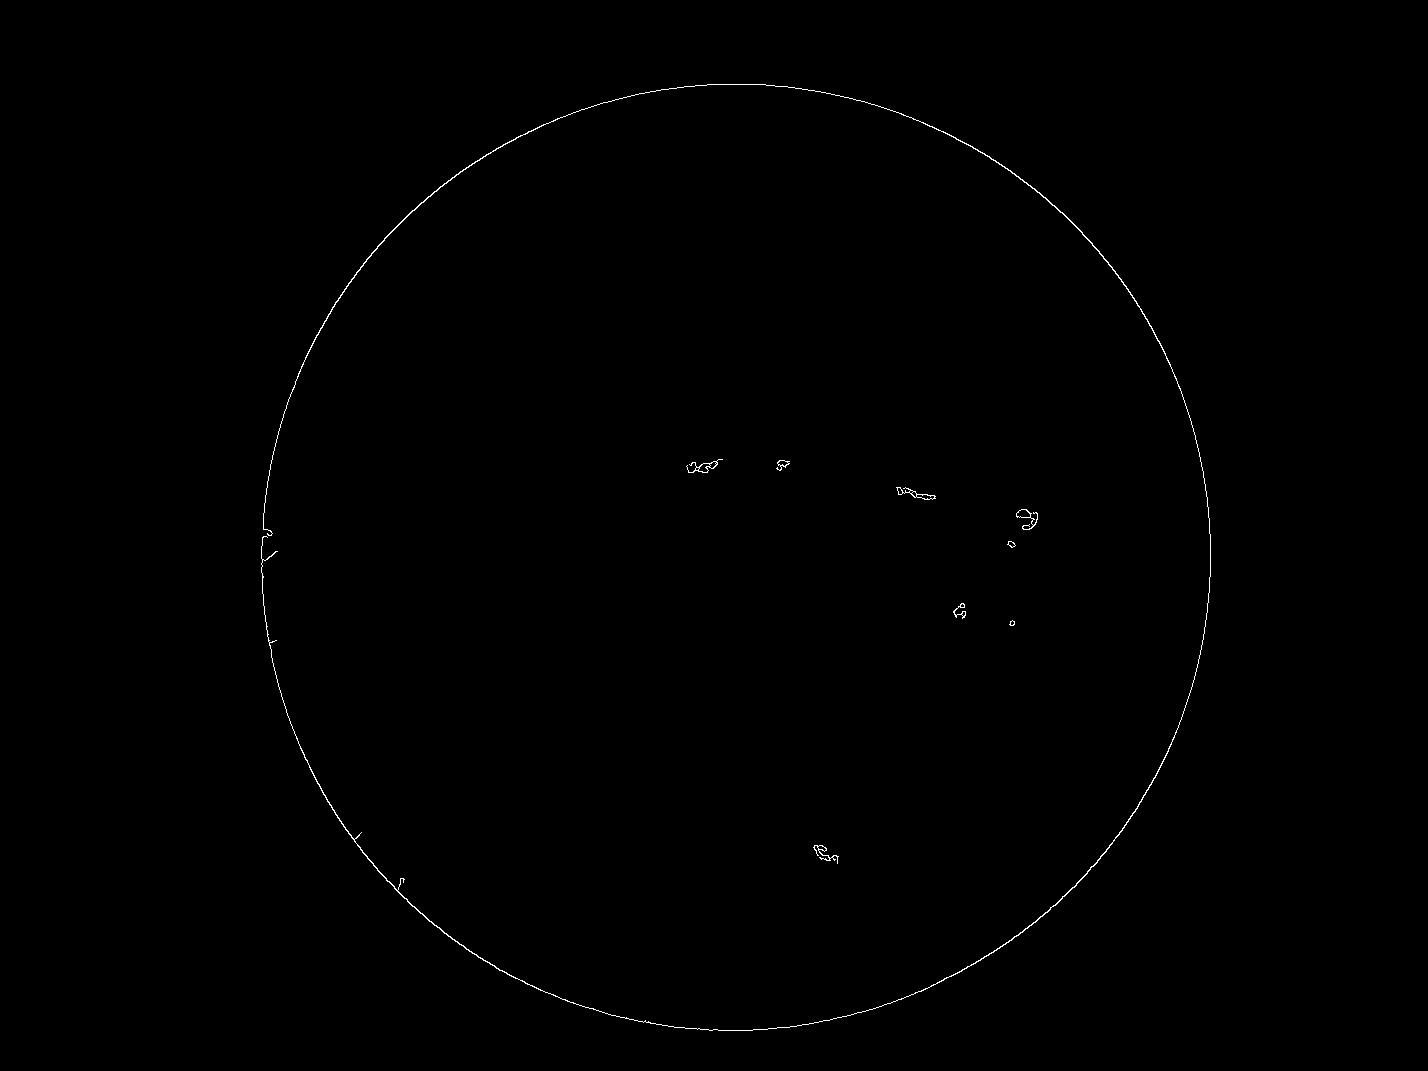

In [ ]:

import cv2
import numpy as np
from PIL import Image
from pillow_heif import register_heif_opener # Import for registering HEIC support

# Habilitar soporte para archivos HEIC en Pillow
register_heif_opener()

# Read the HEIC image using Pillow
img_pil = Image.open('/content/Copy of IMG_4667.HEIC')

# Convert the Pillow image to a NumPy array with the correct data type
image_np = np.array(img_pil)

# Convert from RGB (Pillow) to BGR (OpenCV)
image_bgr = cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR)
# ... rest of your code
# Scale factor
scale = 0.25

# Calculate new dimensions
new_width = int(image_np.shape[1] * scale)
new_height = int(image_np.shape[0] * scale)
new_size = (new_width, new_height)

# Resize the image
resized_image = cv2.resize(image_bgr, new_size, interpolation=cv2.INTER_LINEAR)

gray = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)
lower_threshold = 100
upper_threshold = 500
blurred = cv2.GaussianBlur(gray, (5, 5), 1.3)
edges = cv2.Canny(blurred, lower_threshold, upper_threshold)
cv2_imshow(edges)


Círculo detectado: Centro=(734, 557), Radio=472


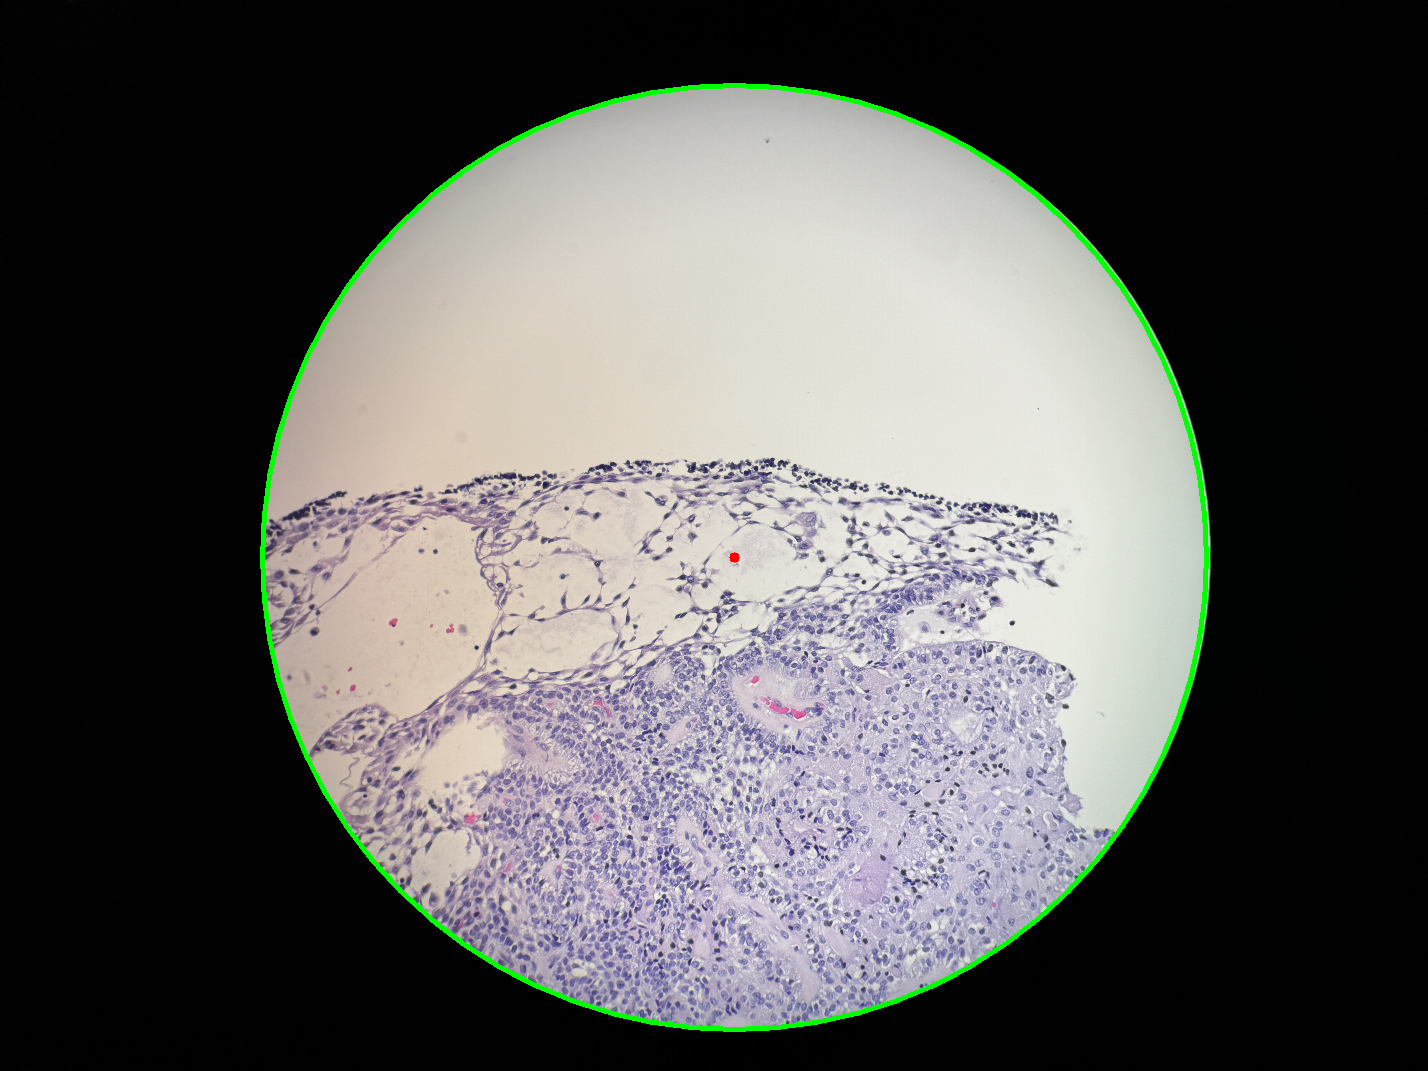

Cuadrado inscrito recortado:


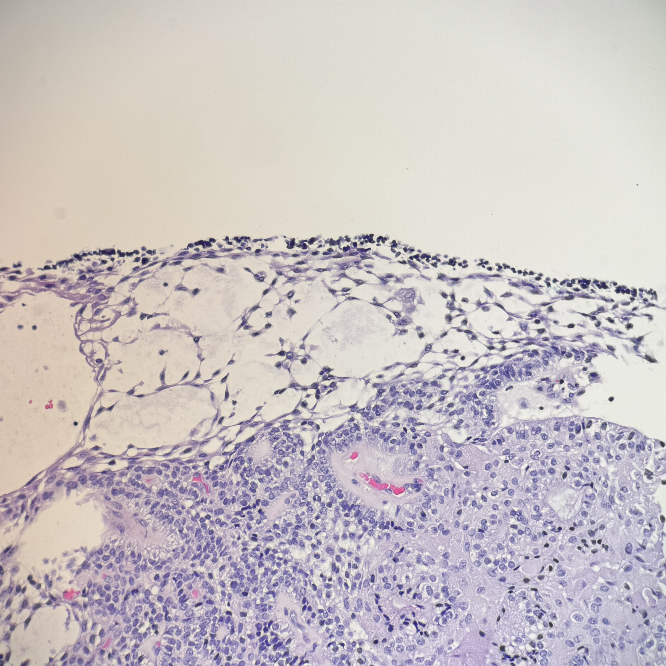

Imagen con círculo guardada como 'circle_detected_with_inscribed_square.jpg'.
Cuadrado recortado guardado como 'inscribed_square_cropped.jpg'.


In [ ]:
def detect_circle_and_crop_inscribed_square(min_radius, max_radius):
    # Cargar la imagen de bordes
    edges_image = edges

    # Detectar círculos en la imagen de bordes usando la Transformada de Hough
    circles = cv2.HoughCircles(
        edges_image,
        cv2.HOUGH_GRADIENT,
        dp=1.2,
        minDist=30,
        param1=50,
        param2=30,
        minRadius=min_radius,
        maxRadius=max_radius,
    )

    if circles is not None:
        # Asegurarse de que los círculos están bien definidos
        circles = np.round(circles[0, :]).astype("int")

        # Seleccionar el círculo más prominente (el más grande)
        most_prominent_circle = max(circles, key=lambda c: c[2])  # Círculo más grande
        x, y, radius = most_prominent_circle

        # Dibujar el círculo en la imagen original
        original_image = resized_image.copy()
        cv2.circle(original_image, (x, y), radius, (0, 255, 0), 3)  # Círculo verde
        cv2.circle(original_image, (x, y), 5, (0, 0, 255), -1)      # Centro en rojo

        # Calcular las coordenadas del cuadrado inscrito
        square_side = int(np.sqrt(2) * radius)  # Lado del cuadrado inscrito
        top_left_x = max(0, x - square_side // 2)
        top_left_y = max(0, y - square_side // 2)
        bottom_right_x = min(resized_image.shape[1], x + square_side // 2)
        bottom_right_y = min(resized_image.shape[0], y + square_side // 2)

        # Recortar la región del cuadrado inscrito
        square_crop = resized_image[top_left_y:bottom_right_y, top_left_x:bottom_right_x]

        # Mostrar la imagen original con el círculo
        print(f"Círculo detectado: Centro=({x}, {y}), Radio={radius}")
        cv2_imshow(original_image)

        # Mostrar el cuadrado recortado
        print("Cuadrado inscrito recortado:")
        cv2_imshow(square_crop)

        # Guardar los resultados
        cv2.imwrite("circle_detected_with_inscribed_square.jpg", original_image)
        cv2.imwrite("inscribed_square_cropped.jpg", square_crop)
        print("Imagen con círculo guardada como 'circle_detected_with_inscribed_square.jpg'.")
        print("Cuadrado recortado guardado como 'inscribed_square_cropped.jpg'.")
    else:
        print("No se detectaron círculos en la imagen de bordes.")
    return square_crop
# Parámetros para la detección de círculos
min_radius = 100        # Radio mínimo del círculo
max_radius = 490        # Radio máximo del círculo

# Detectar círculo y recortar el cuadrado inscrito
square_crop = detect_circle_and_crop_inscribed_square(min_radius, max_radius)

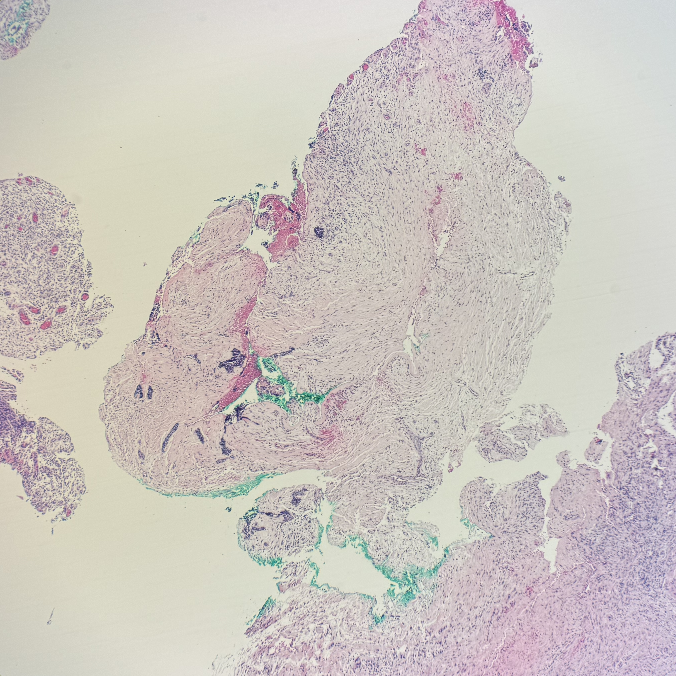

In [ ]:
cv2_imshow(square_crop)

In [ ]:
cv2.imwrite("inscrito.jpg", square_crop)

True

In [ ]:
!ls '/content/drive/MyDrive/GorlinIA/A_D_K_CROPPED/AMELOBLASTOMA/4X'

mi_imagen.png


In [ ]:
type(square_crop)

numpy.ndarray